# Part 3: Hyperparameter selection and model comparison (BP, MLR-F, BP-F)

This notebook uses the preprocessed dataset generated in Part 1 and the custom
Backpropagation implementation from Part 2 to:

1. Explore at least 10 hyperparameter combinations for the custom BP network and
   select a good configuration based on MSE, MAE and MAPE (Part 3.1).
2. Compare the best custom BP model against:
   - A Multiple Linear Regression model (MLR-F, scikit-learn).
   - A Neural Network from a library (BP-F, scikit-learn MLPRegressor).
   (Part 3.2).

All models are trained on the same preprocessed data and evaluated on the same
held-out test set generated in Part 1.


## Block 1 – Imports and loading of preprocessed data

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

from part2_bp_implementation.NeuralNet import NeuralNet

np.random.seed(0)

# ---------------------------------------------------------------------
# Load preprocessed datasets generated in Part 1
# These files are created by part1_generate_files.py
# ---------------------------------------------------------------------
X_train_val = np.load("./dataset/preprocessed/X_train_val.npy")
y_train_val = np.load("./dataset/preprocessed/y_train_val.npy")
X_test = np.load("./dataset/preprocessed/X_test.npy")
y_test = np.load("./dataset/preprocessed/y_test.npy")

# Ensure targets are 2D column vectors (n_samples, 1)
if y_train_val.ndim == 1:
    y_train_val = y_train_val.reshape(-1, 1)
if y_test.ndim == 1:
    y_test = y_test.reshape(-1, 1)

print(f"Train+val X shape: {X_train_val.shape}, y shape: {y_train_val.shape}")
print(f"Test      X shape: {X_test.shape}, y shape: {y_test.shape}")


Train+val X shape: (3120, 134), y shape: (3120, 1)
Test      X shape: (780, 134), y shape: (780, 1)


## Block 2 – Output Scaling and Metrics Utilities

In [74]:
# ---------------------------------------------------------------------
# Standardize the target variable y according to BP.v2
# We use only train+val statistics and then descale predictions for metrics
# ---------------------------------------------------------------------
y_mean = y_train_val.mean(axis=0)
y_std = y_train_val.std(axis=0)
y_std[y_std == 0] = 1.0  # safety

y_train_val_scaled = (y_train_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print("Target standardization:")
print(f"  y_mean: {y_mean}")
print(f"  y_std : {y_std}")


# ---------------------------------------------------------------------
# Metric functions: MSE, MAE, MAPE on original (descaled) units
# ---------------------------------------------------------------------
def regression_metrics(y_true, y_pred):
    """
    Compute MSE, MAE, MAPE between y_true and y_pred (same shape).
    Both must be in original, non-standardized units.
    """
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    mse = float(np.mean((y_true - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    # Avoid division by zero in MAPE
    eps = 1e-8
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100.0)
    return mse, mae, mape


Target standardization:
  y_mean: [60.14295]
  y_std : [23.673935]


## Block 3 – Helper to train your BP with a configuration

In [75]:
def train_custom_bp(config, X_trval, y_trval_scaled,
                    X_te, y_te_scaled, y_te_original,
                    y_mean, y_std):
    """
    Train the custom BP (NeuralNet) with a given hyperparameter configuration.

    config: dict with keys:
        - 'hidden_layers': list, e.g. [15, 8]
        - 'epochs': int
        - 'learning_rate': float
        - 'momentum': float
        - 'activation': str ('sigmoid', 'relu', 'linear', 'tanh')
        - 'validation_split': float in (0,1)

    X_trval: preprocessed input for train+val (n_samples, n_features)
    y_trval_scaled: standardized target for train+val (n_samples, 1)
    X_te: preprocessed input for test (n_samples_test, n_features)
    y_te_scaled: standardized target for test (n_samples_test, 1)
    y_te_original: original target for test (n_samples_test, 1)
    y_mean, y_std: scaling parameters used for standardization

    Returns:
        result dict with:
        - 'config': config
        - 'mse', 'mae', 'mape': metrics on test (original scale)
        - 'train_losses', 'val_losses': raw lists from fit()
        - 'train_errors', 'val_errors': arrays from loss_epochs()
        - 'y_pred': predictions on test (original scale)
    """
    n_features = X_trval.shape[1]
    hidden_layers = config["hidden_layers"]
    epochs = config["epochs"]
    lr = config["learning_rate"]
    momentum = config["momentum"]
    activation = config["activation"]
    val_split = config["validation_split"]

    layers = [n_features] + hidden_layers + [1]

    # Instantiate the custom BP model
    nn = NeuralNet(
        layers=layers,
        learning_rate=lr,
        momentum=momentum,
        fact=activation,
        l1_reg=0.0,
        l2_reg=0.0,
    )

    # Train the model
    train_losses, val_losses = nn.fit(
        X_trval,
        y_trval_scaled,
        epochs=epochs,
        validation_split=val_split,
    )

    # Get error evolution arrays (n_epochs, 2)
    train_errors, val_errors = nn.loss_epochs()

    # Predictions on test (scaled)
    y_pred_scaled = nn.predict(X_te)
    if y_pred_scaled.ndim == 1:
        y_pred_scaled = y_pred_scaled.reshape(-1, 1)

    # Descale predictions back to original units
    y_pred_original = y_pred_scaled * y_std + y_mean

    # Compute metrics on original scale
    mse, mae, mape = regression_metrics(y_te_original, y_pred_original)

    result = {
        "config": config,
        "mse": mse,
        "mae": mae,
        "mape": mape,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "y_pred": y_pred_original,
    }
    return result


## Block 4 – Define the hyperparameter grid

In [76]:
# ---------------------------------------------------------------------
# Hyperparameter grid for the custom BP (Part 3.1)
# At least 10 different combinations
# ---------------------------------------------------------------------
hyperparameter_grid = [
    # (hidden_layers, epochs, lr, momentum, activation)
    {"hidden_layers": [10],    "epochs": 50, "learning_rate": 0.01, "momentum": 0.0,  "activation": "sigmoid"},
    {"hidden_layers": [20],    "epochs": 50, "learning_rate": 0.01, "momentum": 0.9,  "activation": "sigmoid"},
    {"hidden_layers": [15, 8], "epochs": 50, "learning_rate": 0.01, "momentum": 0.9,  "activation": "sigmoid"},
    {"hidden_layers": [15, 8], "epochs": 50, "learning_rate": 0.005,"momentum": 0.9,  "activation": "sigmoid"},
    {"hidden_layers": [15, 8], "epochs": 100,"learning_rate": 0.01, "momentum": 0.9,  "activation": "sigmoid"},
    {"hidden_layers": [32, 16],"epochs": 50, "learning_rate": 0.01, "momentum": 0.9,  "activation": "relu"},
    {"hidden_layers": [32, 16],"epochs": 100,"learning_rate": 0.01, "momentum": 0.9,  "activation": "relu"},
    {"hidden_layers": [64],    "epochs": 50, "learning_rate": 0.005,"momentum": 0.9,  "activation": "relu"},
    {"hidden_layers": [64],    "epochs": 100,"learning_rate": 0.005,"momentum": 0.9,  "activation": "relu"},
    {"hidden_layers": [10, 5], "epochs": 50, "learning_rate": 0.02, "momentum": 0.5,  "activation": "tanh"},
    {"hidden_layers": [20, 10],"epochs": 75, "learning_rate": 0.01, "momentum": 0.5,  "activation": "tanh"},
]

# Add validation split to each config
for cfg in hyperparameter_grid:
    cfg["validation_split"] = 0.2  # 20% of train+val used as validation inside fit


## Block 5 – Searching for hyperparameters for BP

In [77]:
results_bp = []

for i, cfg in enumerate(hyperparameter_grid, start=1):
    print(f"Training custom BP configuration {i}/{len(hyperparameter_grid)}")
    res = train_custom_bp(
        config=cfg,
        X_trval=X_train_val,
        y_trval_scaled=y_train_val_scaled,
        X_te=X_test,
        y_te_scaled=y_test_scaled,
        y_te_original=y_test,
        y_mean=y_mean,
        y_std=y_std,
    )
    results_bp.append(res)

# Build a summary table
rows = []
for res in results_bp:
    cfg = res["config"]
    rows.append({
        "hidden_layers": cfg["hidden_layers"],
        "epochs": cfg["epochs"],
        "learning_rate": cfg["learning_rate"],
        "momentum": cfg["momentum"],
        "activation": cfg["activation"],
        "validation_split": cfg["validation_split"],
        "MAPE": res["mape"],
        "MAE": res["mae"],
        "MSE": res["mse"],
    })

bp_results_df = pd.DataFrame(rows)
bp_results_df_sorted = bp_results_df.sort_values(by="MSE").reset_index(drop=True)
bp_results_df_sorted


Training custom BP configuration 1/11


Epoch 5/50, Training Loss: 1.007544, Validation Loss: 0.974151
Epoch 10/50, Training Loss: 1.006671, Validation Loss: 0.973805
Epoch 15/50, Training Loss: 1.006420, Validation Loss: 0.973695
Epoch 20/50, Training Loss: 1.006281, Validation Loss: 0.973628
Epoch 25/50, Training Loss: 1.006178, Validation Loss: 0.973571
Epoch 30/50, Training Loss: 1.006088, Validation Loss: 0.973516
Epoch 35/50, Training Loss: 1.006000, Validation Loss: 0.973456
Epoch 40/50, Training Loss: 1.005906, Validation Loss: 0.973388
Epoch 45/50, Training Loss: 1.005803, Validation Loss: 0.973309
Epoch 50/50, Training Loss: 1.005684, Validation Loss: 0.973217
Training custom BP configuration 2/11
Epoch 5/50, Training Loss: 0.987509, Validation Loss: 1.048782
Epoch 10/50, Training Loss: 0.986900, Validation Loss: 1.049288
Epoch 15/50, Training Loss: 0.984526, Validation Loss: 1.055900
Epoch 20/50, Training Loss: 0.971586, Validation Loss: 1.104184
Epoch 25/50, Training Loss: 0.951839, Validation Loss: 1.098748
Epoc

,hidden_layers,epochs,learning_rate,momentum,activation,validation_split,MAPE,MAE,MSE
0,"[32, 16]",100,0.010,0.9,relu,0.2,48.258817,20.755868,563.165624
1,[64],50,0.005,0.9,relu,0.2,48.258817,20.755868,563.165624
2,"[32, 16]",50,0.010,0.9,relu,0.2,48.258817,20.755868,563.165624
3,[64],100,0.005,0.9,relu,0.2,48.258817,20.755868,563.165624
4,"[15, 8]",100,0.010,0.9,sigmoid,0.2,48.280441,20.757857,563.265849
5,[10],50,0.010,0.0,sigmoid,0.2,48.650936,20.782307,564.774338
6,"[15, 8]",50,0.005,0.9,sigmoid,0.2,49.007391,20.817069,567.422104
7,"[15, 8]",50,0.010,0.9,sigmoid,0.2,51.384829,21.126464,595.160251
8,[20],50,0.010,0.9,sigmoid,0.2,52.525282,21.671478,632.703394
9,"[10, 5]",50,0.020,0.5,tanh,0.2,51.601931,23.176129,794.260762


## Block 6 – Select the best BP and retrain for graphs

In [78]:
# Select the best configuration according to MAPE (lower is better)
best_idx = bp_results_df_sorted.index[0]
best_config = results_bp[best_idx]["config"]
print("Best BP configuration (by MSE):", best_config)

# Retrain the best configuration to get clean histories and predictions
best_bp_result = train_custom_bp(
    config=best_config,
    X_trval=X_train_val,
    y_trval_scaled=y_train_val_scaled,
    X_te=X_test,
    y_te_scaled=y_test_scaled,
    y_te_original=y_test,
    y_mean=y_mean,
    y_std=y_std,
)

best_bp_mse = best_bp_result["mse"]
best_bp_mae = best_bp_result["mae"]
best_bp_mape = best_bp_result["mape"]

print("Best custom BP test performance:")
print(f"  MSE : {best_bp_mse:.4f}")
print(f"  MAE : {best_bp_mae:.4f}")
print(f"  MAPE: {best_bp_mape:.4f}%")


Best BP configuration (by MSE): {'hidden_layers': [10], 'epochs': 50, 'learning_rate': 0.01, 'momentum': 0.0, 'activation': 'sigmoid', 'validation_split': 0.2}
Epoch 5/50, Training Loss: 0.996984, Validation Loss: 1.018967
Epoch 10/50, Training Loss: 0.996198, Validation Loss: 1.017781
Epoch 15/50, Training Loss: 0.995983, Validation Loss: 1.017361
Epoch 20/50, Training Loss: 0.995865, Validation Loss: 1.017156
Epoch 25/50, Training Loss: 0.995776, Validation Loss: 1.017049
Epoch 30/50, Training Loss: 0.995698, Validation Loss: 1.017006
Epoch 35/50, Training Loss: 0.995620, Validation Loss: 1.016997
Epoch 40/50, Training Loss: 0.995538, Validation Loss: 1.017022
Epoch 45/50, Training Loss: 0.995448, Validation Loss: 1.017070
Epoch 50/50, Training Loss: 0.995348, Validation Loss: 1.017140
Best custom BP test performance:
  MSE : 564.8868
  MAE : 20.7798
  MAPE: 48.6354%


## Block 7 – Scatter plots BP (prediction vs actual) and error curves

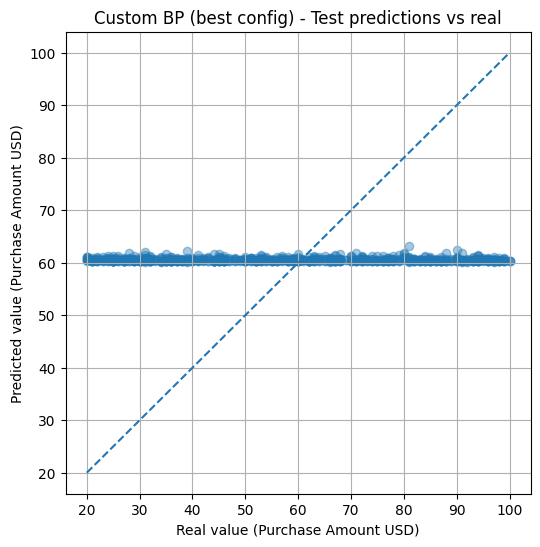

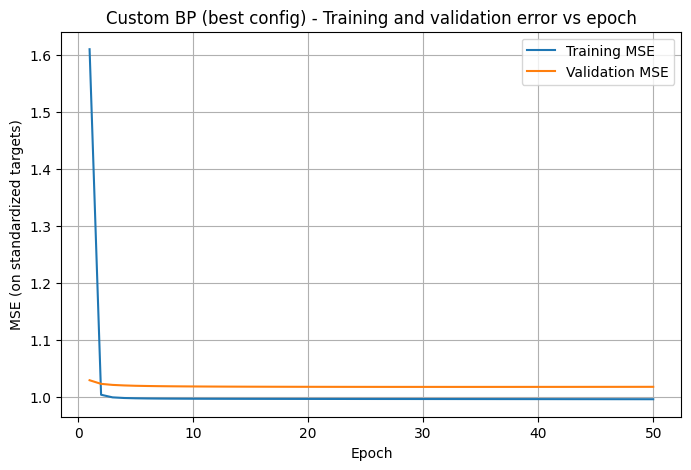

In [79]:
# ---------------------------------------------------------------------
# Scatter plot: predicted vs real for best BP (test set)
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_bp_result["y_pred"], alpha=0.4)
min_val = min(y_test.min(), best_bp_result["y_pred"].min())
max_val = max(y_test.max(), best_bp_result["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Real value (Purchase Amount USD)")
plt.ylabel("Predicted value (Purchase Amount USD)")
plt.title("Custom BP (best config) - Test predictions vs real")
plt.grid(True)
plt.show()

# ---------------------------------------------------------------------
# Training and validation error evolution for best BP
# ---------------------------------------------------------------------
train_errors = best_bp_result["train_errors"][:, 0]
val_errors = best_bp_result["val_errors"][:, 0]
epochs = np.arange(1, len(train_errors) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_errors, label="Training MSE")
plt.plot(epochs, val_errors, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (on standardized targets)")
plt.title("Custom BP (best config) - Training and validation error vs epoch")
plt.legend()
plt.grid(True)
plt.show()


## Block 8 – Training MLR-F

In [80]:
# ---------------------------------------------------------------------
# Multiple Linear Regression (MLR-F) – scikit-learn
# Uses the same preprocessed X and original y (no additional scaling)
# ---------------------------------------------------------------------
mlr_model = LinearRegression()
mlr_model.fit(X_train_val, y_train_val)

y_pred_mlr = mlr_model.predict(X_test)
mse_mlr, mae_mlr, mape_mlr = regression_metrics(y_test, y_pred_mlr)

print("MLR-F (Linear Regression) test performance:")
print(f"  MSE : {mse_mlr:.4f}")
print(f"  MAE : {mae_mlr:.4f}")
print(f"  MAPE: {mape_mlr:.4f}%")


MLR-F (Linear Regression) test performance:
  MSE : 575.1744
  MAE : 20.8824
  MAPE: 48.2672%


## Block 9 – Training BP-F

In [81]:
# ---------------------------------------------------------------------
# BP-F: Neural Network from a library (scikit-learn MLPRegressor)
# We use similar structure to the best BP hidden layers.
# For fairness, we train on standardized targets and descale outputs.
# ---------------------------------------------------------------------
hidden_layers_best = best_config["hidden_layers"]
hidden_layer_sizes = tuple(hidden_layers_best)  # e.g. [15, 8] -> (15, 8)

bpf_model = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes,
    activation="relu",    # you could also try 'logistic' (sigmoid-like)
    solver="adam",
    learning_rate_init=0.01,
    max_iter=300,
    random_state=42,
)

# Train on standardized targets
bpf_model.fit(X_train_val, y_train_val_scaled.ravel())

# Predictions in standardized space, then descale
y_pred_bpf_scaled = bpf_model.predict(X_test).reshape(-1, 1)
y_pred_bpf = y_pred_bpf_scaled * y_std + y_mean

mse_bpf, mae_bpf, mape_bpf = regression_metrics(y_test, y_pred_bpf)

print("BP-F (MLPRegressor) test performance:")
print(f"  MSE : {mse_bpf:.4f}")
print(f"  MAE : {mae_bpf:.4f}")
print(f"  MAPE: {mape_bpf:.4f}%")


BP-F (MLPRegressor) test performance:
  MSE : 822.1814
  MAE : 23.8532
  MAPE: 54.7557%


## Block 10 – Comparison Table BP vs MLR-F vs BP-F

In [82]:
comparison_df = pd.DataFrame(
    [
        {
            "Model": "Custom BP (best)",
            "Hidden layers": best_config["hidden_layers"],
            "Activation": best_config["activation"],
            "Epochs": best_config["epochs"],
            "Learning rate": best_config["learning_rate"],
            "Momentum": best_config["momentum"],
            "MSE": best_bp_mse,
            "MAE": best_bp_mae,
            "MAPE": best_bp_mape,
        },
        {
            "Model": "MLR-F (LinearRegression)",
            "Hidden layers": "-",
            "Activation": "-",
            "Epochs": "-",
            "Learning rate": "-",
            "Momentum": "-",
            "MSE": mse_mlr,
            "MAE": mae_mlr,
            "MAPE": mape_mlr,
        },
        {
            "Model": "BP-F (MLPRegressor)",
            "Hidden layers": list(hidden_layer_sizes),
            "Activation": "relu",
            "Epochs": "max_iter=300",
            "Learning rate": 0.01,
            "Momentum": "adam",
            "MSE": mse_bpf,
            "MAE": mae_bpf,
            "MAPE": mape_bpf,
        },
    ]
)

comparison_df


,Model,Hidden layers,Activation,Epochs,Learning rate,Momentum,MSE,MAE,MAPE
0,Custom BP (best),[10],sigmoid,50,0.01,0.0,564.886807,20.779776,48.635394
1,MLR-F (LinearRegression),-,-,-,-,-,575.174377,20.882404,48.267189
2,BP-F (MLPRegressor),[10],relu,max_iter=300,0.01,adam,822.181396,23.853220,54.755718


## Block 11 – Scatter plots of the three models


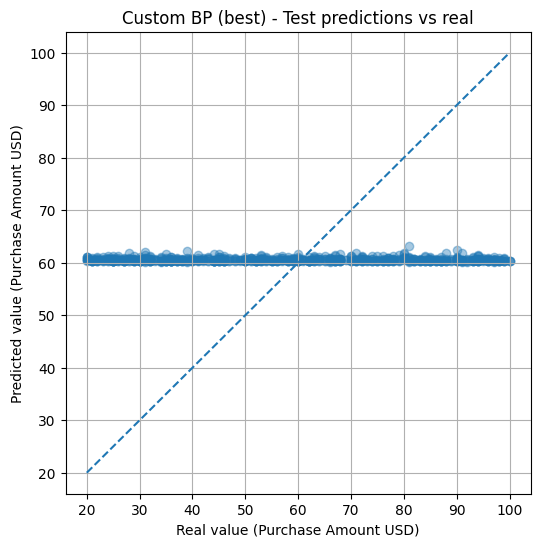

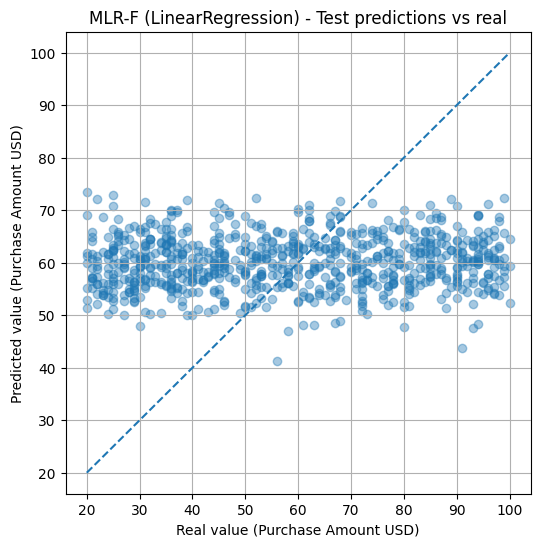

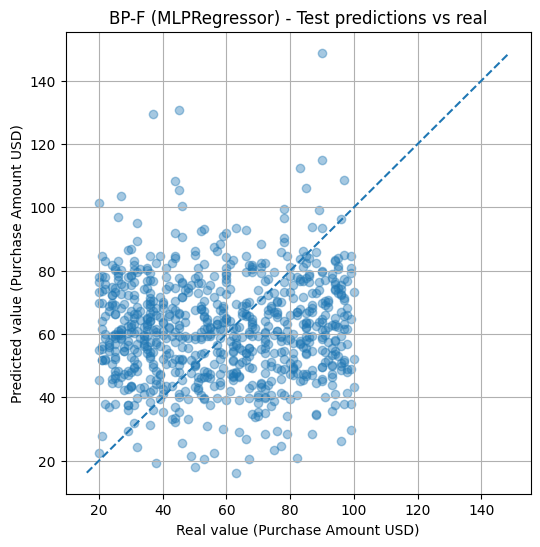

In [83]:
# ---------------------------------------------------------------------
# Scatter plots: predicted vs real for the three models
# ---------------------------------------------------------------------
def scatter_pred_vs_real(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Real value (Purchase Amount USD)")
    plt.ylabel("Predicted value (Purchase Amount USD)")
    plt.title(title)
    plt.grid(True)
    plt.show()


scatter_pred_vs_real(y_test, best_bp_result["y_pred"], "Custom BP (best) - Test predictions vs real")
scatter_pred_vs_real(y_test, y_pred_mlr, "MLR-F (LinearRegression) - Test predictions vs real")
scatter_pred_vs_real(y_test, y_pred_bpf, "BP-F (MLPRegressor) - Test predictions vs real")
